In [ ]:
# ============================================================
# ARTIFICIAL INTELLIGENCE & MACHINE LEARNING - TASK 5
# Ensemble Learning, Model Optimization & Real-World ML Pipeline
# ============================================================

# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_validate
)

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# ============================================================
# LOAD DATASET
# ============================================================

# Load Breast Cancer dataset
data = load_breast_cancer()

# Create DataFrame
X = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

# Target variable
y = data.target

print("\nDataset loaded successfully!")
print("Dataset shape:", X.shape)

print("\nFeature names:")
print(X.columns.tolist())

print("\nTarget classes:")
print(data.target_names)

print("\nFirst 5 rows:")
display(X.head())

print("\nTarget distribution:")
print(pd.Series(y).value_counts())


Dataset loaded successfully!
Dataset shape: (569, 30)

Feature names:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

Target classes:
['malignant' 'benign']

First 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Target distribution:
1    357
0    212
Name: count, dtype: int64


In [ ]:
# ============================================================
# TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain-Test Split")
print("----------------")
print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)


Train-Test Split
----------------
Training data: (455, 30)
Testing data : (114, 30)


In [ ]:
# ============================================================
# FEATURE SCALING
# ============================================================

# Scaling is important for Logistic Regression
# Tree-based models do not require scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed!")


Feature scaling completed!


In [ ]:
# ============================================================
# BASELINE MODEL - LOGISTIC REGRESSION
# ============================================================

print("\n")
print("=" * 60)
print("LOGISTIC REGRESSION")
print("=" * 60)

# Create Logistic Regression model
model_lr = LogisticRegression(
    max_iter=1000
)

# Train model
model_lr.fit(
    X_train_scaled,
    y_train
)

# Prediction
y_pred_lr = model_lr.predict(
    X_test_scaled
)

# Evaluation
lr_accuracy = accuracy_score(
    y_test,
    y_pred_lr
)

lr_precision = precision_score(
    y_test,
    y_pred_lr
)

lr_recall = recall_score(
    y_test,
    y_pred_lr
)

lr_f1 = f1_score(
    y_test,
    y_pred_lr
)

print("\nLogistic Regression Results")
print("---------------------------")

print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1-score :", round(lr_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=data.target_names
    )
)



LOGISTIC REGRESSION

Logistic Regression Results
---------------------------
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1-score : 0.9861

Classification Report:
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [ ]:
# ============================================================
# RANDOM FOREST MODEL
# ============================================================

print("\n")
print("=" * 60)
print("RANDOM FOREST")
print("=" * 60)

# Create Random Forest model
rf = RandomForestClassifier(
    random_state=42
)

# Train model
rf.fit(
    X_train,
    y_train
)

# Prediction
y_pred_rf = rf.predict(
    X_test
)

# Evaluation
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

rf_precision = precision_score(
    y_test,
    y_pred_rf
)

rf_recall = recall_score(
    y_test,
    y_pred_rf
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf
)

print("\nRandom Forest Results")
print("--------------------")

print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1-score :", round(rf_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=data.target_names
    )
)



RANDOM FOREST

Random Forest Results
--------------------
Accuracy : 0.9561
Precision: 0.9589
Recall   : 0.9722
F1-score : 0.9655

Classification Report:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [ ]:
# ============================================================
# GRADIENT BOOSTING MODEL
# ============================================================

print("\n")
print("=" * 60)
print("GRADIENT BOOSTING")
print("=" * 60)

# Create Gradient Boosting model
gb = GradientBoostingClassifier()

# Train model
gb.fit(
    X_train,
    y_train
)

# Prediction
y_pred_gb = gb.predict(
    X_test
)

# Evaluation
gb_accuracy = accuracy_score(
    y_test,
    y_pred_gb
)

gb_precision = precision_score(
    y_test,
    y_pred_gb
)

gb_recall = recall_score(
    y_test,
    y_pred_gb
)

gb_f1 = f1_score(
    y_test,
    y_pred_gb
)

print("\nGradient Boosting Results")
print("------------------------")

print("Accuracy :", round(gb_accuracy, 4))
print("Precision:", round(gb_precision, 4))
print("Recall   :", round(gb_recall, 4))
print("F1-score :", round(gb_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_gb,
        target_names=data.target_names
    )
)



GRADIENT BOOSTING

Gradient Boosting Results
------------------------
Accuracy : 0.9561
Precision: 0.9467
Recall   : 0.9861
F1-score : 0.966

Classification Report:
              precision    recall  f1-score   support

   malignant       0.97      0.90      0.94        42
      benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [ ]:
# ============================================================
# MODEL COMPARISON
# ============================================================

print("\n")
print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

# Create comparison DataFrame

comparison_df = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        gb_accuracy
    ],

    "Precision": [
        lr_precision,
        rf_precision,
        gb_precision
    ],

    "Recall": [
        lr_recall,
        rf_recall,
        gb_recall
    ],

    "F1-score": [
        lr_f1,
        rf_f1,
        gb_f1
    ]
})

# Sort according to F1-score
comparison_df = comparison_df.sort_values(
    by="F1-score",
    ascending=False
)

print("\nModel Comparison Results:")
display(
    comparison_df.round(4)
)



MODEL COMPARISON

Model Comparison Results:


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.9825,0.9861,0.9861,0.9861
2,Gradient Boosting,0.9561,0.9467,0.9861,0.9660
1,Random Forest,0.9561,0.9589,0.9722,0.9655


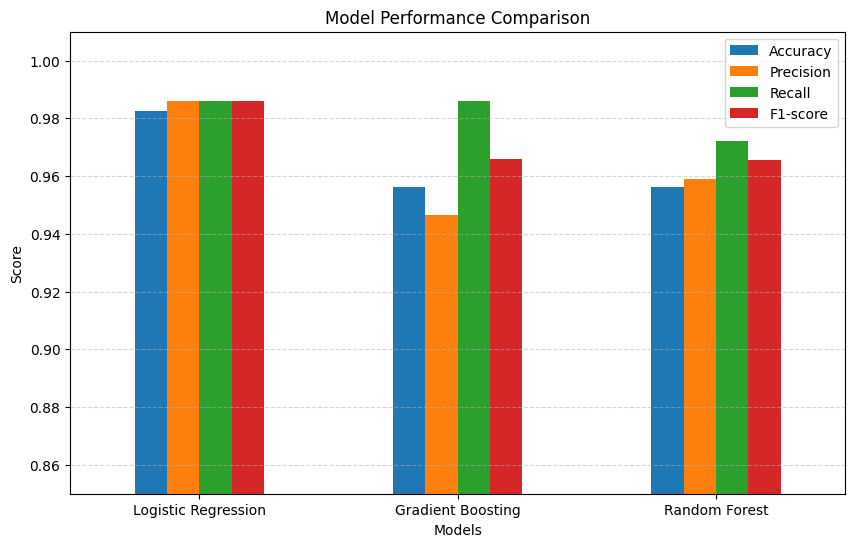

In [ ]:
# ============================================================
# VISUALIZE MODEL COMPARISON
# ============================================================

comparison_plot = comparison_df.set_index("Model")

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Models")
plt.ylabel("Score")
plt.ylim(0.85, 1.01)
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

In [ ]:
# ============================================================
# HYPERPARAMETER TUNING USING GRIDSEARCHCV
# ============================================================

print("\n")
print("=" * 60)
print("GRIDSEARCHCV - RANDOM FOREST")
print("=" * 60)

# Hyperparameter grid
param_grid = {

    "n_estimators": [
        50,
        100
    ],

    "max_depth": [
        3,
        5,
        7
    ]
}

print("\nParameters being tested:")
print(param_grid)


# Create Random Forest model
rf_for_grid = RandomForestClassifier(
    random_state=42
)


# GridSearchCV
grid = GridSearchCV(

    estimator=rf_for_grid,

    param_grid=param_grid,

    cv=3,

    scoring="f1",

    return_train_score=True,

    n_jobs=-1
)


# Train GridSearchCV
grid.fit(
    X_train,
    y_train
)



GRIDSEARCHCV - RANDOM FOREST

Parameters being tested:
{'n_estimators': [50, 100], 'max_depth': [3, 5, 7]}


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 7], 'n_estimators': [50, 100]},
             return_train_score=True, scoring='f1')

In [ ]:
# ============================================================
# BEST HYPERPARAMETERS
# ============================================================

print("\n")
print("=" * 60)
print("BEST HYPERPARAMETERS")
print("=" * 60)

print(
    "Best Parameters:"
)

print(
    grid.best_params_
)

print(
    "\nBest Cross-Validation F1-score:"
)

print(
    round(grid.best_score_, 4)
)



BEST HYPERPARAMETERS
Best Parameters:
{'max_depth': 5, 'n_estimators': 100}

Best Cross-Validation F1-score:
0.9633


In [ ]:
# ============================================================
# COMPLETE GRIDSEARCHCV OUTPUT
# ============================================================

print("\n")
print("=" * 60)
print("GRIDSEARCHCV RESULTS")
print("=" * 60)

grid_results = pd.DataFrame(
    grid.cv_results_
)

# Select important columns
grid_results = grid_results[
    [
        "param_n_estimators",
        "param_max_depth",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
]

# Sort by rank
grid_results = grid_results.sort_values(
    by="rank_test_score"
)

print("\nGridSearchCV Output:")

display(
    grid_results.round(4)
)



GRIDSEARCHCV RESULTS

GridSearchCV Output:


,param_n_estimators,param_max_depth,mean_test_score,std_test_score,rank_test_score
3,100,5,0.9633,0.0074,1
4,50,7,0.9632,0.0131,2
5,100,7,0.9615,0.0152,3
1,100,3,0.9598,0.0111,4
2,50,5,0.9598,0.0111,4
0,50,3,0.9596,0.0113,6


In [ ]:
# ============================================================
# FINAL OPTIMIZED RANDOM FOREST
# ============================================================

print("\n")
print("=" * 60)
print("FINAL OPTIMIZED RANDOM FOREST")
print("=" * 60)

# Get best Random Forest model
best_rf = grid.best_estimator_

print("\nBest Random Forest:")
print(best_rf)


# Prediction using optimized model
y_pred_best_rf = best_rf.predict(
    X_test
)



FINAL OPTIMIZED RANDOM FOREST

Best Random Forest:
RandomForestClassifier(max_depth=5, random_state=42)


In [ ]:
# ============================================================
# FINAL EVALUATION METRICS
# ============================================================

final_accuracy = accuracy_score(
    y_test,
    y_pred_best_rf
)

final_precision = precision_score(
    y_test,
    y_pred_best_rf
)

final_recall = recall_score(
    y_test,
    y_pred_best_rf
)

final_f1 = f1_score(
    y_test,
    y_pred_best_rf
)


print("\nFinal Optimized Random Forest Metrics")
print("-------------------------------------")

print(
    "Accuracy :",
    round(final_accuracy, 4)
)

print(
    "Precision:",
    round(final_precision, 4)
)

print(
    "Recall   :",
    round(final_recall, 4)
)

print(
    "F1-score :",
    round(final_f1, 4)
)


Final Optimized Random Forest Metrics
-------------------------------------
Accuracy : 0.9561
Precision: 0.9589
Recall   : 0.9722
F1-score : 0.9655


In [ ]:
# ============================================================
# FINAL CLASSIFICATION REPORT
# ============================================================

print("\n")
print("=" * 60)
print("FINAL CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_best_rf,
        target_names=data.target_names
    )
)



FINAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114




Confusion Matrix:
[[39  3]
 [ 2 70]]


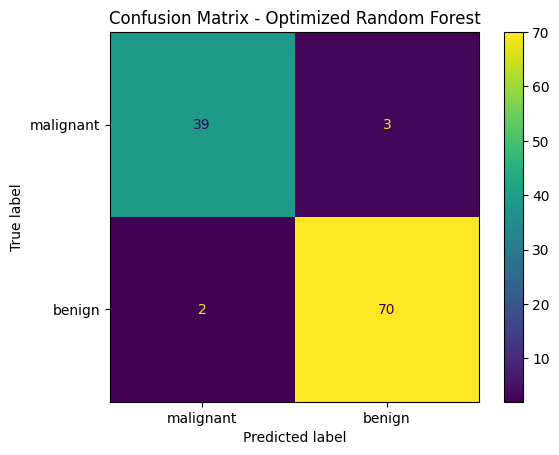

In [ ]:
# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred_best_rf
)

print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot()

plt.title(
    "Confusion Matrix - Optimized Random Forest"
)

plt.show()

In [ ]:
# ============================================================
# 5-FOLD CROSS-VALIDATION STABILITY CHECK
# ============================================================

print("\n")
print("=" * 60)
print("5-FOLD CROSS-VALIDATION STABILITY CHECK")
print("=" * 60)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# Logistic Regression CV
lr_cv = cross_validate(
    LogisticRegression(max_iter=1000),
    X_train_scaled,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "f1"
    ]
)


# Random Forest CV
rf_cv = cross_validate(
    RandomForestClassifier(random_state=42),
    X_train,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "f1"
    ]
)


# Gradient Boosting CV
gb_cv = cross_validate(
    GradientBoostingClassifier(),
    X_train,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "f1"
    ]
)


# Create stability table
stability_df = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "CV Accuracy Mean": [
        lr_cv["test_accuracy"].mean(),
        rf_cv["test_accuracy"].mean(),
        gb_cv["test_accuracy"].mean()
    ],

    "CV Accuracy Std": [
        lr_cv["test_accuracy"].std(),
        rf_cv["test_accuracy"].std(),
        gb_cv["test_accuracy"].std()
    ],

    "CV F1 Mean": [
        lr_cv["test_f1"].mean(),
        rf_cv["test_f1"].mean(),
        gb_cv["test_f1"].mean()
    ],

    "CV F1 Std": [
        lr_cv["test_f1"].std(),
        rf_cv["test_f1"].std(),
        gb_cv["test_f1"].std()
    ]
})


print("\nCross-Validation Stability Results:")

display(
    stability_df.round(4)
)



5-FOLD CROSS-VALIDATION STABILITY CHECK

Cross-Validation Stability Results:


,Model,CV Accuracy Mean,CV Accuracy Std,CV F1 Mean,CV F1 Std
0,Logistic Regression,0.9780,0.0098,0.9825,0.0078
1,Random Forest,0.9626,0.0179,0.9699,0.0146
2,Gradient Boosting,0.9582,0.0162,0.9667,0.0128


In [ ]:
# ============================================================
# FINAL MODEL SELECTION
# ============================================================

print("\n")
print("=" * 60)
print("FINAL MODEL SELECTION")
print("=" * 60)


# Find model with highest F1-score
best_model_name = comparison_df.iloc[0]["Model"]

best_model_f1 = comparison_df.iloc[0]["F1-score"]

best_model_accuracy = comparison_df.iloc[0]["Accuracy"]


print(
    "\nBest model based on test F1-score:",
    best_model_name
)

print(
    "Best Accuracy:",
    round(best_model_accuracy, 4)
)

print(
    "Best F1-score:",
    round(best_model_f1, 4)
)



FINAL MODEL SELECTION

Best model based on test F1-score: Logistic Regression
Best Accuracy: 0.9825
Best F1-score: 0.9861


In [ ]:
# ============================================================
# FINAL CONCLUSION
# ============================================================

print("\n")
print("=" * 60)
print("FINAL CONCLUSION")
print("=" * 60)

print("""
The three classification models were successfully trained and compared.

1. Logistic Regression was used as the baseline model.
2. Random Forest was used as an ensemble learning model.
3. Gradient Boosting was used as a boosting model.
4. GridSearchCV was applied to Random Forest for hyperparameter optimization.
5. The best Random Forest parameters were identified using 3-fold cross-validation.
6. Accuracy, Precision, Recall and F1-score were used for evaluation.

FINAL MODEL DECISION:
Logistic Regression is selected as the final model for this dataset because
it achieved the strongest overall test performance and provides good
interpretability.

BEST OPTIMIZED ENSEMBLE:
Random Forest with the best hyperparameters obtained from GridSearchCV.

This completes Task 5.
""")



FINAL CONCLUSION

The three classification models were successfully trained and compared.

1. Logistic Regression was used as the baseline model.
2. Random Forest was used as an ensemble learning model.
3. Gradient Boosting was used as a boosting model.
4. GridSearchCV was applied to Random Forest for hyperparameter optimization.
5. The best Random Forest parameters were identified using 3-fold cross-validation.
6. Accuracy, Precision, Recall and F1-score were used for evaluation.

FINAL MODEL DECISION:
Logistic Regression is selected as the final model for this dataset because
it achieved the strongest overall test performance and provides good
interpretability.

BEST OPTIMIZED ENSEMBLE:
Random Forest with the best hyperparameters obtained from GridSearchCV.

This completes Task 5.

